In [1]:
!pip install -q -U transformers accelerate pillow matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 34.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 64.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 55.5 MB/s eta 0:00:00


In [3]:
!pip uninstall -y Pillow PIL
!pip install --no-cache-dir --force-reinstall Pillow

Found existing installation: pillow 12.3.0
Uninstalling pillow-12.3.0:
  Successfully uninstalled pillow-12.3.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 49.3 MB/s eta 0:00:00


In [1]:
import torch
import matplotlib.pyplot as plt

from PIL import Image, ImageDraw, ImageFont
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection
from google.colab import files

In [2]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU is not enabled.")
    print("Use Runtime → Change runtime type → T4 GPU")

Device: cpu
GPU is not enabled.
Use Runtime → Change runtime type → T4 GPU


In [3]:
MODEL_NAME = "google/owlvit-base-patch32"

print("Loading processor...")

processor = AutoProcessor.from_pretrained(
    MODEL_NAME
)

print("Loading OWL-ViT model...")

model = AutoModelForZeroShotObjectDetection.from_pretrained(
    MODEL_NAME
)

model = model.to(device)
model.eval()

print("OWL-ViT model loaded successfully.")

Loading processor...


preprocessor_config.json:   0%|          | 0.00/392 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.42k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/775 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.06M [00:00<?, ?B/s]

...

Loading OWL-ViT model...


model.safetensors: reconstructing file:   0%|          |  0.00B /  613MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/412 [00:00<?, ?it/s]

OWL-ViT model loaded successfully.


In [4]:
uploaded_files = files.upload()

Saving vehicles.jpg to vehicles.jpg


Uploaded file: vehicles.jpg
Image size: (1500, 1100)


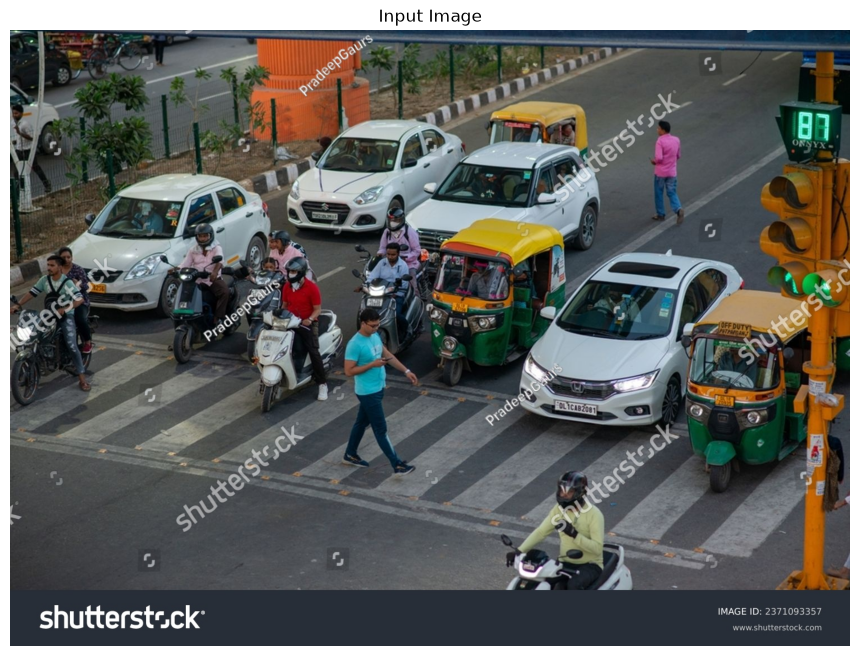

In [5]:
uploaded_filename = next(iter(uploaded_files))

image = Image.open(
    uploaded_filename
).convert("RGB")

print("Uploaded file:", uploaded_filename)
print("Image size:", image.size)

plt.figure(figsize=(12, 8))
plt.imshow(image)
plt.axis("off")
plt.title("Input Image")
plt.show()

In [6]:
candidate_labels = [
    "person",
    "car",
    "bus",
    "bicycle",
    "dog",
    "cat",
    "traffic light"
]

print("The model will search for:")

for label in candidate_labels:
    print("-", label)

The model will search for:
- person
- car
- bus
- bicycle
- dog
- cat
- traffic light


In [7]:
text_labels = [candidate_labels]

inputs = processor(
    text=text_labels,
    images=image,
    return_tensors="pt"
)

inputs = {
    key: value.to(device)
    for key, value in inputs.items()
}

print("Image and text labels prepared successfully.")

Image and text labels prepared successfully.


In [8]:
with torch.inference_mode():
    outputs = model(**inputs)

print("Object detection completed.")

Object detection completed.


In [9]:
CONFIDENCE_THRESHOLD = 0.15

target_sizes = [
    (image.height, image.width)
]

results = processor.post_process_grounded_object_detection(
    outputs=outputs,
    target_sizes=target_sizes,
    threshold=CONFIDENCE_THRESHOLD,
    text_labels=text_labels
)

result = results[0]

print("Predictions processed successfully.")

Predictions processed successfully.


In [10]:
detections = []

boxes = result["boxes"]
scores = result["scores"]
detected_labels = result["text_labels"]

for box, score, label in zip(
    boxes,
    scores,
    detected_labels
):
    coordinates = [
        round(value, 2)
        for value in box.tolist()
    ]

    confidence = float(score.item())

    detections.append(
        {
            "label": label,
            "confidence": confidence,
            "box": coordinates
        }
    )

if not detections:
    print(
        "No requested objects were detected "
        "above the confidence threshold."
    )
else:
    print("Number of objects detected:", len(detections))
    print("-" * 80)

    for index, detection in enumerate(
        detections,
        start=1
    ):
        print(
            f"{index}. "
            f"Object: {detection['label']}, "
            f"Confidence: {detection['confidence']:.2%}, "
            f"Box: {detection['box']}"
        )

Number of objects detected: 1
--------------------------------------------------------------------------------
1. Object: car, Confidence: 16.32%, Box: [483.14, 154.26, 823.82, 369.68]


In [11]:
annotated_image = image.copy()

draw = ImageDraw.Draw(annotated_image)

try:
    font = ImageFont.truetype(
        "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf",
        18
    )
except OSError:
    font = ImageFont.load_default()

line_width = max(
    2,
    round(min(image.size) / 250)
)

for detection in detections:
    x_min, y_min, x_max, y_max = detection["box"]

    label = detection["label"]
    confidence = detection["confidence"]

    label_text = f"{label}: {confidence:.1%}"

    # Draw bounding box
    draw.rectangle(
        [
            (x_min, y_min),
            (x_max, y_max)
        ],
        outline="red",
        width=line_width
    )

    # Calculate label dimensions
    text_bounds = draw.textbbox(
        (0, 0),
        label_text,
        font=font
    )

    text_width = text_bounds[2] - text_bounds[0]
    text_height = text_bounds[3] - text_bounds[1]

    text_x = max(0, int(x_min))

    text_y = max(
        0,
        int(y_min) - text_height - 10
    )

    # Draw label background
    draw.rectangle(
        [
            (text_x, text_y),
            (
                text_x + text_width + 10,
                text_y + text_height + 10
            )
        ],
        fill="red"
    )

    # Draw label
    draw.text(
        (text_x + 5, text_y + 5),
        label_text,
        fill="white",
        font=font
    )

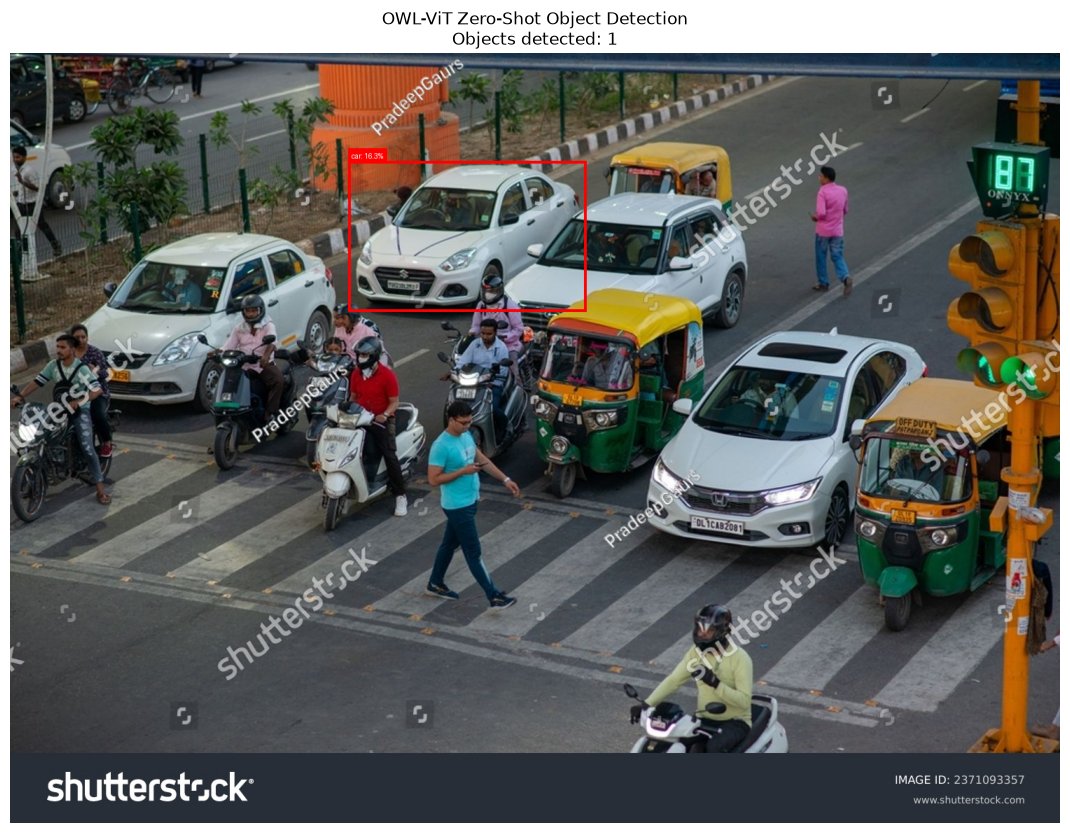

In [12]:
plt.figure(figsize=(14, 10))

plt.imshow(annotated_image)

plt.axis("off")

plt.title(
    "OWL-ViT Zero-Shot Object Detection\n"
    f"Objects detected: {len(detections)}"
)

plt.show()

In [13]:
OUTPUT_FILENAME = "owlvit_detection_result.jpg"

annotated_image.save(
    OUTPUT_FILENAME,
    quality=95
)

print("Saved as:", OUTPUT_FILENAME)

files.download(OUTPUT_FILENAME)

Saved as: owlvit_detection_result.jpg


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>